# Across-problem analysis (from scratch)
This notebook loads `subjects_trials_by_problem` and produces requested across-problem plots.


In [1]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Make project imports work (assumes notebook is in repo or run from a place where ../src exists)
sys.path.insert(0, str(Path.cwd().parent))

from src.behavior_import.import_data import *
from src.behavior_import.extract_trials import *
from src.behavior_analysis.get_total_reversals import *
from src.behavior_analysis.get_good_reversal_info import *
from fix_grid_maze_cohort_02_problems import *

# ---- plot style ----
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial"]
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 14

MOUSE_COLORS = [
    "#4C72B0","#55A868","#C44E52","#8172B2",
    "#CCB974","#64B5CD","#8C8C8C","#DD8452",
    "#937860","#DA8BC3","#8C6D31","#1F77B4",
]


In [2]:
# --- USER CELL (as requested) ---
task = "grid-maze"

folder_name = None
cohort = None
if task == "grid-maze":
    cohort = "cohort-02"
    folder_name = "3x3_maze_blocked_reward_bandit"
elif task == "open-field":
    cohort = "cohort-01"
    folder_name = "3x3_field_blocked_reward_bandit"
root = f"/Volumes/behrens/meg/{folder_name}/{cohort}/rawdata/"

subjects_data = import_data(root)
subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)
if task == "grid-maze" and cohort == "cohort-02":
    subjects_trials_by_problem = fix_grid_maze_cohort_02_problems(subjects_trials_by_problem)

# quick peek
list(subjects_trials_by_problem.keys())[:10], len(subjects_trials_by_problem)


[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-27_date-20260124/behav/._MY_04_R-2026-01-24-124422.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-55_date-20260209/behav/._MY_04_R-2026-02-09-103918.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-28_date-20260124/behav/._MY_04_R-2026-01-24-165301.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-12_date-20260116/behav/._MY_04_R-2026-01-16-143640.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volum

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 11)

In [3]:
# Change this as needed
cutoff_problem = 7


In [4]:
# ---------- helpers ----------
def problem_to_int(k):
    if isinstance(k, (int, np.integer)):
        return int(k)
    m = re.search(r"(\d+)", str(k))
    return int(m.group(1)) if m else None

_ses_re = re.compile(r"ses-(\d+)")
def session_sort_key(session_key: str):
    m = _ses_re.search(str(session_key))
    return int(m.group(1)) if m else str(session_key)

def flatten_trials(subject_trials):
    """subject_trials can be a list[trial_dict] or dict[session_key -> list[trial_dict]]."""
    if subject_trials is None:
        return []
    if isinstance(subject_trials, list):
        return subject_trials
    if isinstance(subject_trials, dict):
        out = []
        for sk in sorted(subject_trials.keys(), key=session_sort_key):
            out.extend(subject_trials[sk])
        return out
    raise TypeError(f"Unexpected subject_trials type: {type(subject_trials)}")

def get_session_map(subject_trials):
    """Return dict[session_key -> list[trial_dict]]; if input is list, returns {'__all__': list}."""
    if subject_trials is None:
        return {}
    if isinstance(subject_trials, dict):
        return subject_trials
    if isinstance(subject_trials, list):
        return {'__all__': subject_trials}
    raise TypeError(f"Unexpected subject_trials type: {type(subject_trials)}")

def summarize_by_problem(per_mouse_metric):
    """per_mouse_metric: dict[mouse -> dict[problem_int -> float]]"""
    mice = sorted(per_mouse_metric.keys())
    problems = sorted({p for m in mice for p in per_mouse_metric[m].keys()})
    means, ses, ns = [], [], []
    for p in problems:
        vals = np.array([per_mouse_metric[m][p] for m in mice if p in per_mouse_metric[m]], dtype=float)
        n = int(vals.size)
        ns.append(n)
        if n == 0:
            means.append(np.nan); ses.append(np.nan)
        elif n == 1:
            means.append(float(vals.mean())); ses.append(0.0)
        else:
            means.append(float(vals.mean()))
            ses.append(float(vals.std(ddof=1) / np.sqrt(n)))
    return {"blocks": problems, "means": means, "ses": ses, "ns": ns, "per_mouse_blocklens": per_mouse_metric, "mice": mice}

def plot_metric_by_problem(summary, *, title, ylabel, jitter=0.06, annotate_y=None):
    blocks = summary["blocks"]
    means = np.asarray(summary["means"], dtype=float)
    ses = np.asarray(summary["ses"], dtype=float)
    ns = summary["ns"]
    per_mouse = summary["per_mouse_blocklens"]
    mice = summary["mice"]

    mouse_to_color = {m: MOUSE_COLORS[i % len(MOUSE_COLORS)] for i, m in enumerate(mice)}

    fig, ax = plt.subplots(figsize=(10, 4.8))
    x = np.arange(len(blocks))

    ax.bar(
        x, means, yerr=ses, capsize=6,
        edgecolor="black", linewidth=1.5, alpha=0.55,
        color=["#999999"] * len(blocks), zorder=1
    )

    finite_top = np.nanmax(means + ses) if np.any(np.isfinite(means + ses)) else 1.0
    if annotate_y is None:
        annotate_y = max(float(finite_top), 1.0) * 1.5

    for xi, mval in zip(x, means):
        if np.isfinite(mval):
            ax.text(xi, annotate_y, f"{mval:.2f}", ha="center", va="bottom", fontsize=12, clip_on=False)

    legend_handles = []
    for m in mice:
        d = per_mouse.get(m, {})
        xs, ys = [], []
        for bi, b in enumerate(blocks):
            if b in d:
                xs.append(bi); ys.append(d[b])
        if not xs:
            continue
        xs = np.asarray(xs, float); ys = np.asarray(ys, float)
        if jitter > 0:
            xs = xs + np.random.uniform(-jitter, jitter, size=len(xs))
        c = mouse_to_color[m]
        ax.plot(xs, ys, color=c, linewidth=2.5, alpha=0.9, marker="o", markersize=6, zorder=3)
        legend_handles.append(Line2D([0],[0], color=c, lw=2.5, marker="o", label=f"{m} (n={len(ys)})"))

    ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in blocks], fontsize=12)
    ax.set_xlabel("Problem Number", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, pad=18)

    top_needed = max(annotate_y, float(finite_top))
    ax.set_ylim(0, top_needed * 1.02)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 1) Number of sessions per problem (mean ± SE across mice + per-mouse lines)


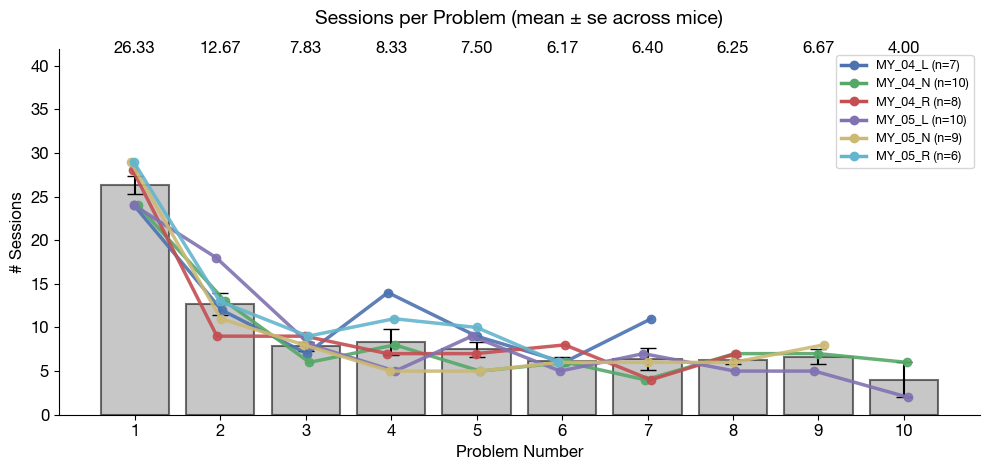

In [5]:
# Build per-mouse: problem -> n_sessions
per_mouse_sessions = {}

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None:
        continue
    for mouse, subj_trials in subj_map.items():
        sess_map = get_session_map(subj_trials)
        n_sessions = len(sess_map)
        per_mouse_sessions.setdefault(mouse, {})[p] = float(n_sessions)

# Ignore the last problem (largest p) for each mouse
for mouse, pmap in per_mouse_sessions.items():
    if not pmap:
        continue
    last_p = max(pmap.keys())
    pmap.pop(last_p, None)

summary_sessions = summarize_by_problem(per_mouse_sessions)

plot_metric_by_problem(
    summary_sessions,
    title="Sessions per Problem (mean ± se across mice)",
    ylabel="# Sessions",
    jitter=0.06
)

## 2) Number of reversals per problem
For problems < cutoff: **good reversals**. For problems ≥ cutoff: **total (good+bad)**.


[SKIP] MY_05_L boundary@401 (good_reversals, block 8): reward magnitudes before were [4, 0, 0] across towers ['A3', 'A1', 'C3'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
[SKIP] MY_04_L boundary@103 (good_reversals, block 3): reward magnitudes before were [0, 0, 4] across towers ['B1', 'A1', 'C1'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
[SKIP] MY_05_L boundary@146 (good_reversals, block 4): reward magnitudes before were [4, 0, 0] across towers ['B1', 'A1', 'C1'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
[SKIP] MY_04_N boundary@186 (good_reversals, block 7): reward magnitudes before were [4, 0, 0] across towers ['B2', 'C2', 'A2'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])


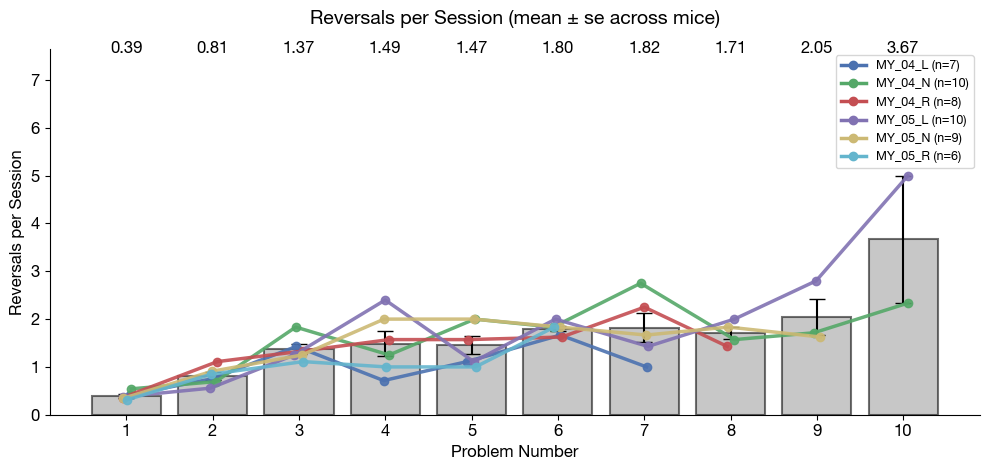

In [6]:
per_mouse_reversals = {}

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None:
        continue

    rw = get_good_reversal_info(subj_map, include_first_block=False)

    # Normalize rw to dict[mouse] -> {"good": [...], "bad": [...]}
    rw_norm = {}
    for mouse, v in rw.items():
        if isinstance(v, dict) and ("good" in v or "bad" in v):
            rw_norm[mouse] = {"good": list(v.get("good", [])), "bad": list(v.get("bad", []))}
        elif isinstance(v, list):
            rw_norm[mouse] = {"good": v, "bad": []}
        else:
            rw_norm[mouse] = {"good": [], "bad": []}

    rw = rw_norm

    for mouse, subj_trials in subj_map.items():

        g = len(rw.get(mouse, {}).get("good", []))
        b = len(rw.get(mouse, {}).get("bad", []))

        total_rev = g if p < cutoff_problem else (g + b)

        sess_map = get_session_map(subj_trials)
        n_sessions = len(sess_map)

        if n_sessions == 0:
            continue

        val = total_rev / n_sessions

        per_mouse_reversals.setdefault(mouse, {})[p] = float(val)


# ---- EXCLUDE LAST PROBLEM PER MOUSE ----
for mouse, pmap in per_mouse_reversals.items():
    if not pmap:
        continue
    last_p = max(pmap.keys())
    pmap.pop(last_p, None)


summary_reversals = summarize_by_problem(per_mouse_reversals)

plot_metric_by_problem(
    summary_reversals,
    title=f"Reversals per Session (mean ± se across mice)",
    ylabel="Reversals per Session",
    jitter=0.06
)

## 3) Mean block length per problem
For problems < cutoff: boundary = **good**. For problems ≥ cutoff: boundary = **all**.

Block length is computed from reversal indices as differences between consecutive boundaries (including start at 0), then averaged within each mouse for that problem.


[SKIP] MY_05_L boundary@401 (good_reversals, block 8): reward magnitudes before were [4, 0, 0] across towers ['A3', 'A1', 'C3'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
[SKIP] MY_04_L boundary@103 (good_reversals, block 3): reward magnitudes before were [0, 0, 4] across towers ['B1', 'A1', 'C1'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
[SKIP] MY_05_L boundary@146 (good_reversals, block 4): reward magnitudes before were [4, 0, 0] across towers ['B1', 'A1', 'C1'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
[SKIP] MY_04_N boundary@186 (good_reversals, block 7): reward magnitudes before were [4, 0, 0] across towers ['B2', 'C2', 'A2'] (expected a permutation of one of [(4, 1, 0), (3, 1, 0), (2, 1, 0)])
finite counts per problem: {1: 6, 2: 6, 3: 6, 4: 6, 5: 6, 6: 6, 7: 5, 8: 4, 9: 3, 10: 2}
problems present in per_mouse_blocklen: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


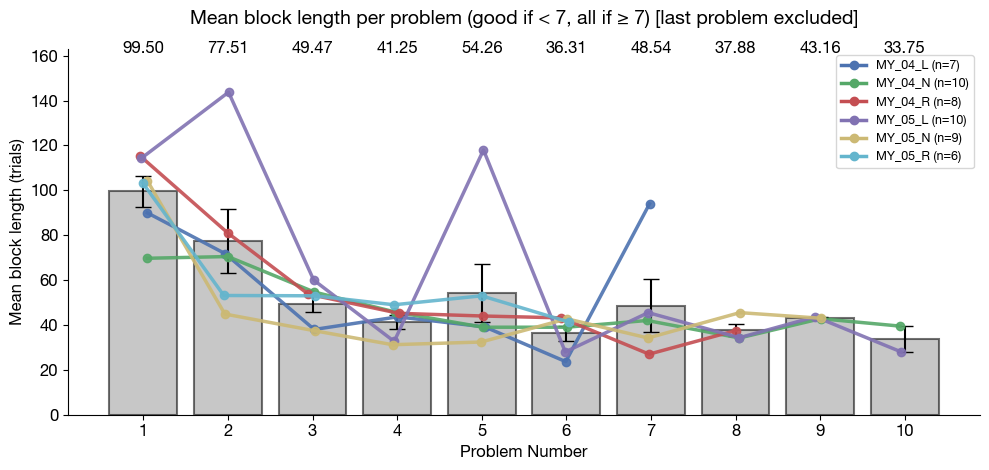

In [7]:
import numpy as np

def mean_block_length_from_indices(idxs, T):
    # idxs: reversal indices (ints) within [0, T)
    idxs = [int(i) for i in idxs if 0 <= int(i) < T]
    idxs = sorted(set(idxs))
    boundaries = [0] + idxs
    if len(boundaries) == 1:
        return np.nan
    lens = np.diff(boundaries)
    if lens.size == 0:
        return np.nan
    return float(np.mean(lens))

def flatten_trials_by_session(trials_by_session):
    """trials_by_session: dict[session_id -> list[trial_dict]]"""
    if not isinstance(trials_by_session, dict):
        # already flat
        return list(trials_by_session)
    out = []
    for _, sess_trials in trials_by_session.items():
        if sess_trials:
            out.extend(sess_trials)
    return out

per_mouse_blocklen = {}

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None:
        continue

    rw = get_good_reversal_info(subj_map, include_first_block=False)

    # Normalize rw to dict[mouse] -> {"good": [...], "bad": [...]}
    rw_norm = {}
    for mouse, v in rw.items():
        if isinstance(v, dict) and ("good" in v or "bad" in v):
            rw_norm[mouse] = {"good": list(v.get("good", [])), "bad": list(v.get("bad", []))}
        elif isinstance(v, list):
            rw_norm[mouse] = {"good": list(v), "bad": []}
        else:
            rw_norm[mouse] = {"good": [], "bad": []}
    rw = rw_norm

    for mouse, trials_by_session in subj_map.items():
        trials_flat = flatten_trials_by_session(trials_by_session)
        T = len(trials_flat)
        if T == 0:
            continue

        if p < cutoff_problem:
            rev_events = rw.get(mouse, {}).get("good", [])
        else:
            rev_events = rw.get(mouse, {}).get("good", []) + rw.get(mouse, {}).get("bad", [])

        # rev_events are dicts like {"reversal_idx": ...} in your printout
        idxs = []
        for r in rev_events:
            if isinstance(r, dict) and "reversal_idx" in r:
                idxs.append(r["reversal_idx"])
            elif isinstance(r, (int, float, np.integer)):
                idxs.append(int(r))

        per_mouse_blocklen.setdefault(mouse, {})[p] = float(mean_block_length_from_indices(idxs, T))

# Exclude last problem per mouse
for mouse, pmap in per_mouse_blocklen.items():
    if pmap:
        pmap.pop(max(pmap.keys()), None)

import numpy as np
from collections import Counter

# how many mice have a finite value at each problem?
finite_counts = Counter()
for mouse, pmap in per_mouse_blocklen.items():
    for p, v in pmap.items():
        if np.isfinite(v):
            finite_counts[p] += 1

print("finite counts per problem:", dict(sorted(finite_counts.items())))
print("problems present in per_mouse_blocklen:", sorted({p for pm in per_mouse_blocklen.values() for p in pm}))

summary_blocklen = summarize_by_problem(per_mouse_blocklen)

plot_metric_by_problem(
    summary_blocklen,
    title=f"Mean block length per problem (good if < {cutoff_problem}, all if ≥ {cutoff_problem}) [last problem excluded]",
    ylabel="Mean block length (trials)",
    jitter=0.06
)

## 4) Distribution of trials per session (all mice), only for problems ≥ cutoff


In [8]:
import numpy as np
import re
from datetime import datetime

def sort_session_id(session_id: str):
    """
    Match the same logic you used in group_sessions_by_problem:
    sort by ses-XX then date-YYYYMMDD, then session_id.
    """
    m_ses = re.search(r"ses-(\d+)", session_id)
    m_date = re.search(r"date-(\d{8})", session_id)

    ses_num = int(m_ses.group(1)) if m_ses else float("inf")
    dt = datetime.strptime(m_date.group(1), "%Y%m%d") if m_date else datetime.max
    return (ses_num, dt, session_id)

def n_trials_in_session(sess: dict) -> int:
    """
    Robustly compute #trials for one session_data dict produced by extract_trials().

    Priority:
      1) 'trial' variable list (standardized)
      2) length of 'choice' list
      3) flatten 'trial_info' (list-of-lists of trial dicts)
    """
    if not isinstance(sess, dict):
        return 0

    # Most reliable if present
    trial_seq = sess.get("trial", None)
    if isinstance(trial_seq, (list, tuple)):
        return len(trial_seq)

    choice_seq = sess.get("choice", None)
    if isinstance(choice_seq, (list, tuple)):
        return len(choice_seq)

    trial_info = sess.get("trial_info", None)
    if isinstance(trial_info, list):
        # trial_info is a list of segments (one per file), each is list[trial_dict]
        total = 0
        for seg in trial_info:
            if isinstance(seg, list):
                total += len(seg)
        return total

    return 0

def total_trials_in_problem(mouse_sessions: dict) -> int:
    """
    mouse_sessions: dict[session_id -> session_data]
    """
    if not isinstance(mouse_sessions, dict):
        return 0
    return sum(n_trials_in_session(sess) for sess in mouse_sessions.values())

def mean_block_length_from_indices(idxs, T):
    """
    idxs: list[int] reversal indices in [0, T)
    T: total #trials in the (flattened) problem sequence
    Returns mean block length in trials (between boundaries [0] + idxs).
    """
    if T <= 0:
        return np.nan

    clean = []
    for i in idxs:
        try:
            ii = int(i)
        except Exception:
            continue
        if 0 <= ii < T:
            clean.append(ii)

    clean = sorted(set(clean))
    boundaries = [0] + clean
    if len(boundaries) <= 1:
        return np.nan

    lens = np.diff(boundaries)
    if lens.size == 0:
        return np.nan

    return float(np.mean(lens))

def exclude_last_problem_per_mouse(per_mouse_metric: dict):
    """
    per_mouse_metric: dict[mouse -> dict[problem_int -> value]]
    Removes the max problem key per mouse (their last problem).
    """
    for mouse, pmap in per_mouse_metric.items():
        if isinstance(pmap, dict) and pmap:
            last_p = max(pmap.keys())
            pmap.pop(last_p, None)
    return per_mouse_metric

def summarize_by_problem_safe(per_mouse_metric: dict):
    """
    If your summarize_by_problem() is fine, you can ignore this.
    This is a common fix for “bar missing when only one mouse contributes”:
    - mean computed fine
    - SE becomes NaN (n=1) and some plotting code skips drawing bars

    Output format matches the usual summarize_by_problem shape:
      {problem: {"mean": ..., "se": ..., "n": ..., "values": [...]}}
    """
    by_p = {}
    for mouse, pmap in per_mouse_metric.items():
        if not isinstance(pmap, dict):
            continue
        for p, v in pmap.items():
            if v is None or not np.isfinite(v):
                continue
            by_p.setdefault(p, []).append(float(v))

    out = {}
    for p, vals in by_p.items():
        vals = np.asarray(vals, dtype=float)
        n = int(np.isfinite(vals).sum())
        if n == 0:
            continue
        m = float(np.nanmean(vals))
        if n == 1:
            se = 0.0
        else:
            se = float(np.nanstd(vals, ddof=1) / np.sqrt(n))
        out[p] = {"mean": m, "se": se, "n": n, "values": vals.tolist()}
    return out

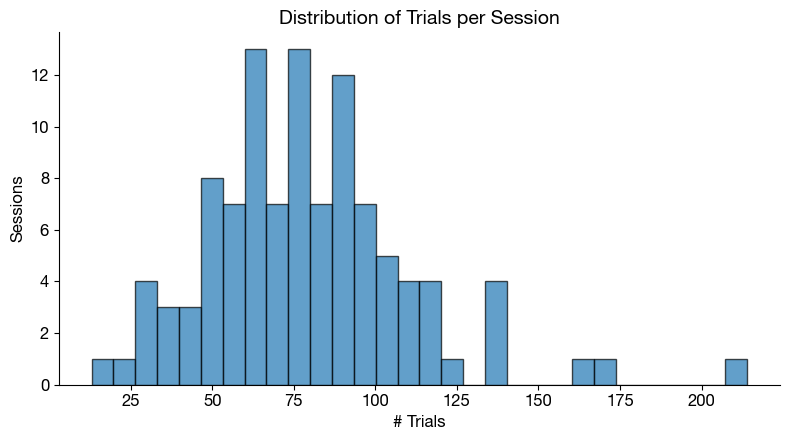

Sessions counted: 107
Median trials/session: 76.0 | Mean: 79.20560747663552
Unique trial counts (first 25): [13. 21. 29. 32. 33. 37. 39. 42. 43. 46. 47. 49. 51. 52. 53. 54. 55. 56.
 58. 60. 61. 62. 63. 64. 65.]


In [9]:
trial_counts = []

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None or p < cutoff_problem:
        continue

    # subj_map: dict[mouse -> dict[session_id -> session_data]]
    for mouse, sessions in subj_map.items():
        if not isinstance(sessions, dict):
            continue

        for session_id, sess in sessions.items():
            nT = n_trials_in_session(sess)
            if nT > 0:
                trial_counts.append(nT)

trial_counts = np.asarray(trial_counts, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(trial_counts[np.isfinite(trial_counts)], bins=30, edgecolor="black", alpha=0.7)
ax.set_title(f"Distribution of Trials per Session")
ax.set_xlabel("# Trials")
ax.set_ylabel("Sessions")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig)

print("Sessions counted:", int(np.isfinite(trial_counts).sum()))
print("Median trials/session:", float(np.nanmedian(trial_counts)), "| Mean:", float(np.nanmean(trial_counts)))
print("Unique trial counts (first 25):", np.unique(trial_counts)[:25])

## 5) Distribution of total reversals per session (all mice), only for problems ≥ cutoff


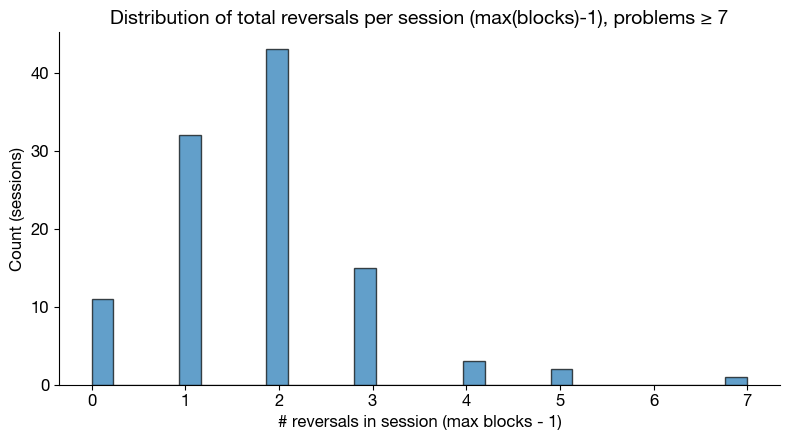

Sessions counted: 107
Median reversals/session: 2.0 | Mean: 1.794392523364486


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def reversals_from_blocks_counter(session_data):
    """
    Returns (max(num_blocks) - 1) for the session.
    Uses standardized key 'blocks' which you build from ALIASES ("num_blocks", ...).
    """
    blocks_seq = session_data.get("blocks", None)

    if blocks_seq is None:
        return np.nan

    # blocks_seq should be list-like per trial; keep only numeric-ish entries
    vals = []
    for x in blocks_seq:
        if x is None:
            continue
        try:
            vals.append(float(x))
        except Exception:
            pass

    if len(vals) == 0:
        return np.nan

    max_blocks = np.nanmax(np.asarray(vals, dtype=float))
    if not np.isfinite(max_blocks):
        return np.nan

    # reversals = (#blocks - 1)
    return float(max(0.0, max_blocks - 1.0))

rev_counts = []

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None or p < cutoff_problem:
        continue

    # subj_map[mouse] is dict[session_id -> session_data]
    for mouse, sessions in subj_map.items():
        if not isinstance(sessions, dict):
            continue
        for sess_id, session_data in sessions.items():
            rev_counts.append(reversals_from_blocks_counter(session_data))

rev_counts = np.asarray(rev_counts, dtype=float)
vals = rev_counts[np.isfinite(rev_counts)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(vals, bins=30, edgecolor="black", alpha=0.7)
ax.set_title(f"Distribution of total reversals per session (max(blocks)-1), problems ≥ {cutoff_problem}")
ax.set_xlabel("# reversals in session (max blocks - 1)")
ax.set_ylabel("Count (sessions)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig)

print("Sessions counted:", int(vals.size))
print("Median reversals/session:", float(np.nanmedian(vals)) if vals.size else np.nan,
      "| Mean:", float(np.nanmean(vals)) if vals.size else np.nan)

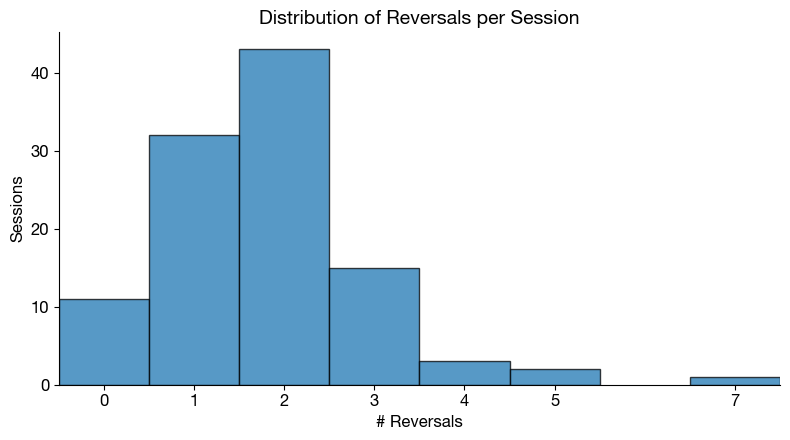

Sessions counted: 107
Median: 2.0 | Mean: 1.794392523364486


In [11]:
import numpy as np
import matplotlib.pyplot as plt

vals = rev_counts[np.isfinite(rev_counts)].astype(int)

if vals.size == 0:
    print("No sessions found.")
else:
    uniq, counts = np.unique(vals, return_counts=True)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.bar(
        uniq,
        counts,
        width=1.0,            # full integer width → no gaps
        align="center",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.75
    )

    ax.set_title(
        f"Distribution of Reversals per Session"
    )
    ax.set_xlabel("# Reversals")
    ax.set_ylabel("Sessions")

    ax.set_xticks(uniq)
    ax.set_xlim(uniq.min() - 0.5, uniq.max() + 0.5)
    ax.margins(x=0)          # remove extra padding

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print("Sessions counted:", int(vals.size))
    print("Median:", float(np.median(vals)), "| Mean:", float(np.mean(vals)))

## 6) Distribution of # sessions per problem across mice, only for problems ≥ cutoff
This treats each (mouse, problem) as one datapoint: how many sessions did that mouse contribute to that problem?


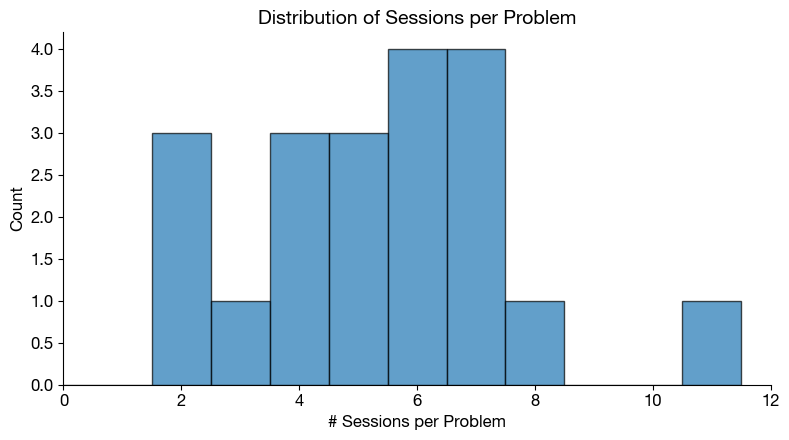

,mouse,problem,n_sessions
0,MY_05_R,7,4
1,MY_04_R,7,4
2,MY_05_N,7,6
3,MY_04_L,7,11
4,MY_05_L,7,7


Mouse×problem datapoints: 20 | Mice: 6 | Problems: 5
Median sessions/problem: 5.5 | Mean: 5.35


In [12]:
vals = []
rows = []

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None or p < cutoff_problem:
        continue
    for mouse, subj_trials in subj_map.items():
        n_sessions = len(get_session_map(subj_trials))
        vals.append(n_sessions)
        rows.append({"mouse": mouse, "problem": p, "n_sessions": n_sessions})

df_sessions_dist = pd.DataFrame(rows)
vals = np.asarray(vals, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(vals[np.isfinite(vals)], bins=np.arange(0, np.nanmax(vals)+2) - 0.5 if vals.size else 10, edgecolor="black", alpha=0.7)
ax.set_title(f"Distribution of Sessions per Problem")
ax.set_xlabel("# Sessions per Problem")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0,12)
plt.tight_layout()
plt.show()
plt.close(fig)

display(df_sessions_dist.head())
print("Mouse×problem datapoints:", len(df_sessions_dist), "| Mice:", df_sessions_dist["mouse"].nunique(), "| Problems:", df_sessions_dist["problem"].nunique())
print("Median sessions/problem:", float(np.nanmedian(vals)), "| Mean:", float(np.nanmean(vals)))
